In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [13]:
np.random.seed(42)
dates = pd.date_range(start="2024-01-01", periods=500, freq='D')
dates

DatetimeIndex(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04',
               '2024-01-05', '2024-01-06', '2024-01-07', '2024-01-08',
               '2024-01-09', '2024-01-10',
               ...
               '2025-05-05', '2025-05-06', '2025-05-07', '2025-05-08',
               '2025-05-09', '2025-05-10', '2025-05-11', '2025-05-12',
               '2025-05-13', '2025-05-14'],
              dtype='datetime64[us]', length=500, freq='D')

In [5]:
base_sales = 50000 
trend = np.arange(500) * 50  #
noise = np.random.normal(0, 5000, 500)  #
weekly_sales = base_sales + trend + noise

In [14]:
df_sales = pd.DataFrame({'Date': dates, 'Weekly_Sales': weekly_sales})
df_sales

,Date,Weekly_Sales
0,2024-01-01,52483.570765
1,2024-01-02,49358.678494
2,2024-01-03,53338.442691
3,2024-01-04,57765.149282
4,2024-01-05,49029.233126
...,...,...
495,2025-05-10,77444.550218
496,2025-05-11,69613.769228
497,2025-05-12,73898.306610
498,2025-05-13,70521.908733


In [7]:
df_sales['Month'] = df_sales['Date'].dt.month
df_sales['Year'] = df_sales['Date'].dt.year

In [ ]:
X = df_sales[['Month', 'Year']] 
y = df_sales['Weekly_Sales']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 1582.27,18334.42]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Month','Year']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.706e+07
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2


In [10]:

predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

In [11]:
print(f"Mean Absolute Error (Average galti): ₹{mae:.2f}")
print(f"R2 Score (Model Accuracy): {r2 * 100:.2f}%")

Mean Absolute Error (Average galti): ₹3687.20
R2 Score (Model Accuracy): 72.23%


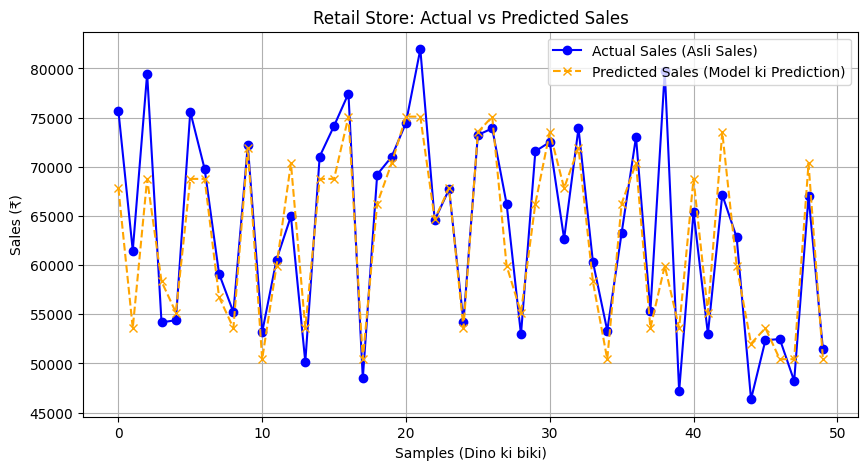

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:50], label='Actual Sales (Asli Sales)', color='blue', marker='o')
plt.plot(predictions[:50], label='Predicted Sales (Model ki Prediction)', color='orange', linestyle='--', marker='x')
plt.title('Retail Store: Actual vs Predicted Sales')
plt.xlabel('Samples (Dino ki biki)')
plt.ylabel('Sales (₹)')
plt.legend()
plt.grid(True)
plt.show()